In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    FunctionTransformer,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    SplineTransformer,
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.compose import make_column_transformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score


In [2]:
# Revisit the OKCupid data
df = pd.read_csv("../04_categorical/profiles_revised.csv")

In [3]:
# Target: predict if job is stem related
df["job"].value_counts()
df["stem_job"] = df["job"].str.contains("computer|science", case=False, na=False)
df["stem_job"].value_counts() / len(df)
df.drop(columns="job", inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   ethnicity    54266 non-null  object 
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   offspring    24385 non-null  object 
 10  orientation  59946 non-null  object 
 11  pets         40025 non-null  object 
 12  religion     39720 non-null  object 
 13  sex          59946 non-null  object 
 14  sign         48890 non-null  object 
 15  smokes       54434 non-null  object 
 16  speaks       59896 non-null  object 
 17  status       59946 non-null  object 
 18  stem_job     59946 non-null  bool   
dtypes: b

## Understanding missing values
In addition to looking at how many of which feature are missing, it's useful to understand whether missing values tend to co-occur.

In [5]:
# Store a copy before we mess with it
og_df = df.copy()

In [6]:
# set income < 0 to missing
df.loc[df["income"] < 0, "income"] = np.nan
df.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status,stem_job
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,NaN,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single,False
1,36,average,mostly other,often,sometimes,working on space camp,white,70.0,80000.0,"doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single,False
2,37,thin,anything,socially,NaN,graduated from masters program,NaN,68.0,NaN,NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available,False
3,22,thin,vegetarian,socially,NaN,working on college/university,white,71.0,20000.0,doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single,False
4,30,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",66.0,NaN,NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single,False


In [7]:
print("Missing values by percentage of dataset")
df.isna().sum().sort_values(ascending=False) / len(df) * 100

Missing values by percentage of dataset


income         80.809395
offspring      59.321723
diet           40.694959
religion       33.740366
pets           33.231575
drugs          23.487806
sign           18.443266
education      11.056618
ethnicity       9.475194
smokes          9.194942
body_type       8.834618
drinks          4.979482
speaks          0.083408
height          0.005005
age             0.000000
orientation     0.000000
sex             0.000000
status          0.000000
stem_job        0.000000
dtype: float64

Text(0, 0.5, 'Number of samples')

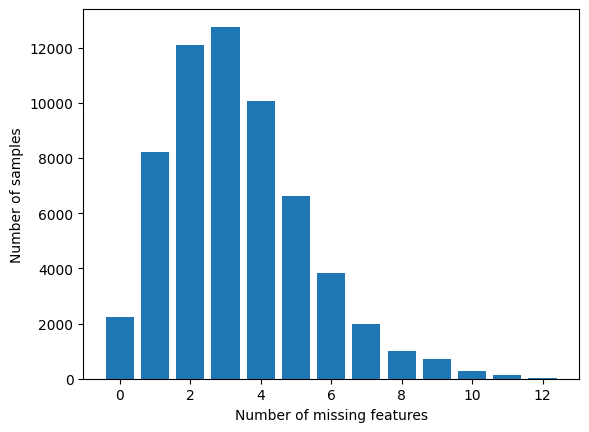

In [8]:
# How many missing values per sample?
missing_per_sample = df.isna().sum(axis=1).value_counts()
plt.bar(missing_per_sample.index, missing_per_sample)
plt.xlabel("Number of missing features")
plt.ylabel("Number of samples")

<Axes: >

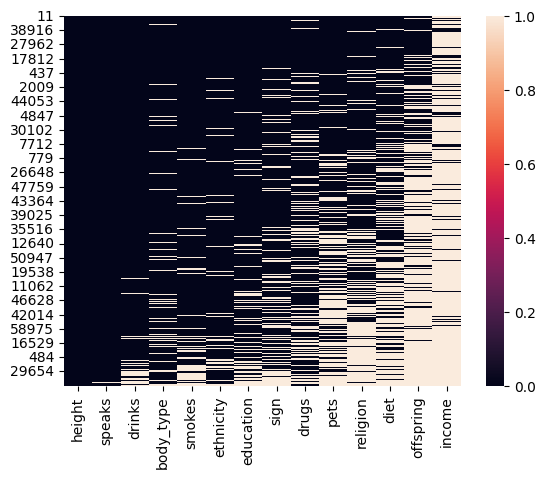

In [9]:
# Maybe a heatmap can show trends?
# number of missing per sample
missing_samples = df.isna().sum(axis=1).sort_values()
# drop with none missing and sort 
missing_samples.drop(missing_samples[missing_samples == 0].index, inplace=True)

# Features with samples missing
missing_features = df.isna().sum(axis=0).sort_values()
missing_features.drop(missing_features[missing_features == 0].index, inplace=True)

sns.heatmap(df.loc[missing_samples.index, missing_features.index].isna())

In [10]:
df.loc[missing_samples.index, missing_features.index].isna()

,height,speaks,drinks,body_type,smokes,ethnicity,education,sign,drugs,pets,religion,diet,offspring,income
11,False,False,False,False,False,False,False,False,False,False,False,False,True,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10484,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10479,False,False,False,False,False,False,False,False,False,False,False,False,False,True
10477,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17837,False,False,True,True,True,True,True,True,True,True,True,True,True,True
38797,False,False,True,True,True,True,True,True,True,True,True,True,True,True
37355,False,False,True,True,True,True,True,True,True,True,True,True,True,True
54200,False,False,True,True,True,True,True,True,True,True,True,True,True,True


<Axes: >

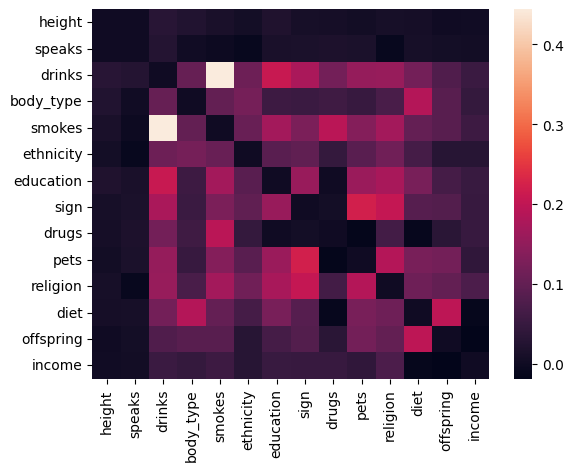

In [11]:
# how about correlations between missing values?
missing_cor = df.loc[missing_samples.index, missing_features.index].isna().corr()
# zero out the diagonal so we can visualize it better
missing_cor -= np.identity(missing_cor.shape[0])
sns.heatmap(missing_cor)

In [12]:
# before looking at relationship to target, split the data
train, test = train_test_split(df, stratify=df["stem_job"], random_state=12345)

income       36329
offspring    26598
diet         18268
religion     15231
pets         14973
drugs        10512
dtype: int64


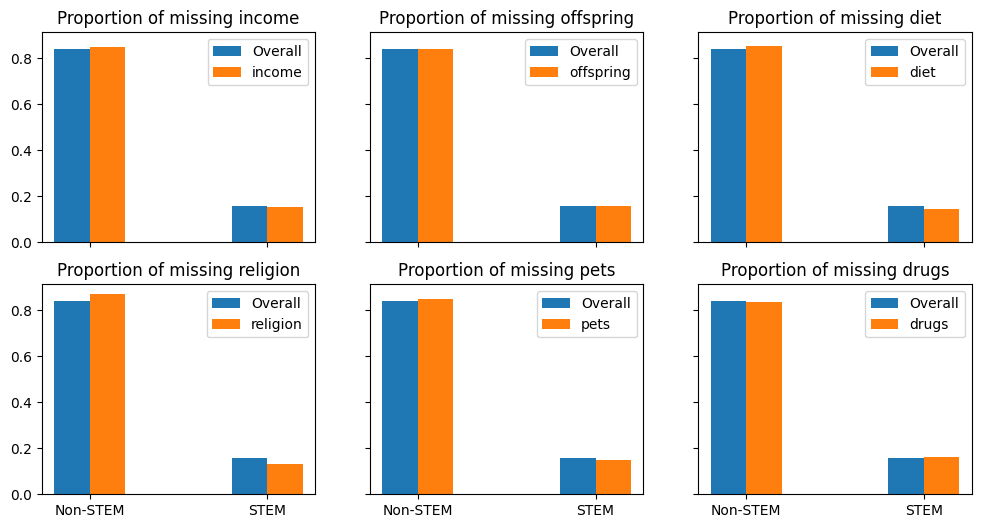

In [13]:
# look at the ones that have a lot missing
train_missing = train.isna().sum(axis=0).sort_values(ascending=False)
# filter down to the > 20% missing
n_missing = train_missing[train_missing > 0.2 * len(train)]
print(n_missing)

# percentage in each target category
train_prop = train["stem_job"].value_counts() / len(train)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for feat, ax in zip(n_missing.index, axes.flatten()):
    counts = train.groupby("stem_job")[feat].apply(lambda x: x.isna().sum())
    # normalize
    counts /= n_missing[feat]
    # compare to the overall proportion of stem/not stem
    ax.bar([-0.1, .9], train_prop, width=0.2, label="Overall")
    ax.bar([0.1, 1.1], counts, width=0.2, label=f"{feat}")
    ax.set_xticks([0, 1], labels=["Non-STEM", "STEM"])
    ax.set_title(f"Proportion of missing {feat}")
    ax.legend()

# Look at value_counts for the features with lots of missing data, grouped by stem_job


## Dealing with missing values

In [14]:
# select features to use in the model
numeric_features = ["age", "height", "income"]
cat_features = ["drinks", "education", "sex"]

In [15]:
# Define the trickier encoders
drink_enc = OrdinalEncoder(
            categories=[
                [
                    "not at all",
                    "rarely",
                    "socially",
                    "often",
                    "very often",
                    "desperately",
                ]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )

# This took a while mucking around to figure out the right magic between df/series
def split_edu(df):
    edu = df["education"].copy()
    edu[edu.isna()] = ""
    return edu.str.split(" ")

edu_enc = make_pipeline(
        FunctionTransformer(split_edu, validate=False),
        FeatureHasher(n_features=8, input_type="string"),
    )


In [16]:
df["education"].str.split(" ")

0            [working, on, college/university]
1                   [working, on, space, camp]
2          [graduated, from, masters, program]
3            [working, on, college/university]
4        [graduated, from, college/university]
                         ...                  
59941    [graduated, from, college/university]
59942        [working, on, college/university]
59943      [graduated, from, masters, program]
59944        [working, on, college/university]
59945      [graduated, from, masters, program]
Name: education, Length: 59946, dtype: object

In [17]:
# Build the preprocessing pipeline

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="mean", add_indicator=True),
    PowerTransformer(method="yeo-johnson"),
)

preprocessor = make_column_transformer(
    (numeric_pipeline, numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), ["sex"]), # sparse_output = False for pandas output
    (drink_enc, ["drinks"]),
    (edu_enc, ["education"]), # can't be converted to pandas
    
)#.set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [18]:
X_pro = preprocessor.fit_transform(train)

In [19]:
# check that there are no nans
np.isnan(X_pro).any()

np.False_

In [20]:
# Now add on a model!
pipeline = make_pipeline(
    preprocessor,
    SGDClassifier(class_weight="balanced"), #class_weight="balanced" does some magic
)

cross_val_score(pipeline, train, train["stem_job"], scoring="recall")

array([0.69295185, 0.68967922, 0.67503487, 0.68479777, 0.68876483])

## Extra plots used in slides

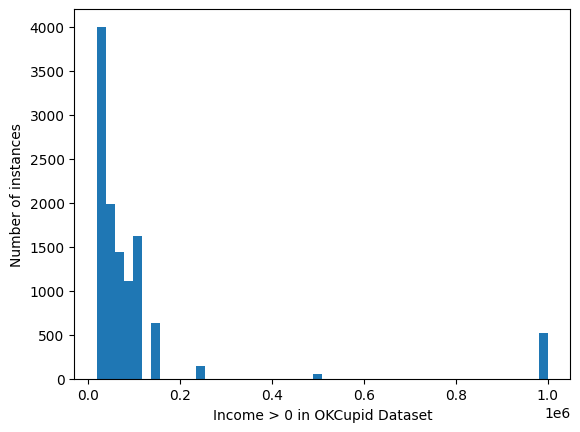

In [21]:
# assume -1 is encoding missingness
plt.hist(df[df["income"] > 0]["income"], bins=50)
plt.xlabel("Income > 0 in OKCupid Dataset")
plt.ylabel("Number of instances")
plt.savefig("../../static/img/06-income-hist.png")

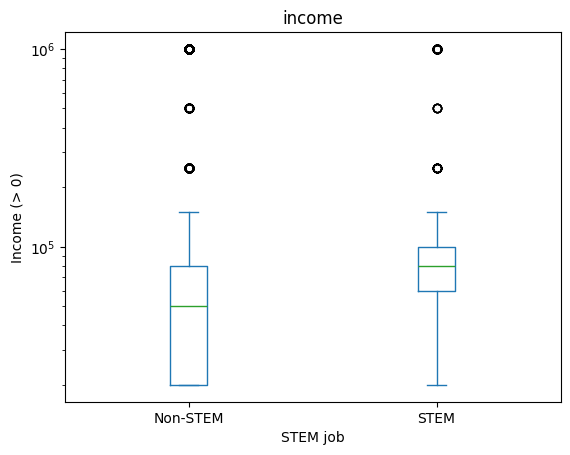

In [22]:
# What about boxplots vs STEM?
# Only use the training data since we're looking at relationship with predictor
plot_df = train[train["income"] > 0]
fig, ax = plt.subplots()
plot_df.plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")
plt.savefig("../../static/img/06-income-boxplot.png")

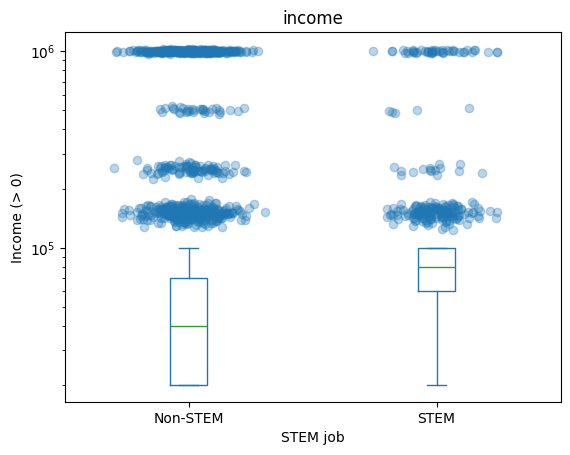

In [23]:
# Those outliers are all overlapping, try spreading them out with jitter
fig, ax = plt.subplots()
plot_df.query("income < 140000").plot.box(column="income", ax=ax,by="stem_job")
ax.set_xlabel("STEM job")
ax.set_xticks([1,2], labels=["Non-STEM", "STEM"])
ax.set_ylabel("Income (> 0)")
plt.yscale("log")

# we need a random number generator
rng = np.random.default_rng(seed=67)
outliers = plot_df.query("income >= 140000")
jit_x = rng.normal(size=outliers.shape[0], scale=0.1) + 1 + outliers["stem_job"] * 1
jit_y = rng.normal(size=outliers.shape[0], scale=10000) + outliers["income"] 
plt.scatter(jit_x, jit_y, alpha=0.3)
